In [3]:
! kaggle auth login

Your browser has been opened to visit:
  https://www.kaggle.com/api/v1/oauth2/authorize?response_type=code&client_id=kagglesdk&redirect_uri=http%3A%2F%2Flocalhost%3A8574&scope=resources.admin%3A%2A&state=eaf748f8-da9f-44f2-8801-6e6a057eb0b6&code_challenge=9e6aUzQZN3VKsCaHifTaBpX59HbOb_nGIV4L4VfPu7g%3D&code_challenge_method=S256&response_mode=query


127.0.0.1 - - [25/May/2026 12:59:16] "GET /?code=CfDJ8KXhJwB4GRRPqJWFH0ywOel7EquG8vEHAQ1frOKxPLlkO2nG6unCyQ5YCOLVdaKOB2ppoy_iY2vo0h6UxhhCHoo55Z3LeWCnE4LisOGR3UkBGZG5SbgOoN7ixGA5EKjey2MMTSa1C9Uq6efomBPLksSTlnwYhkvcnUIGOGAvfCAIZoj8mM4WSwtmx3lHR7JrHofg5i_QSSJkk51VDt7pXuCsOwsp9gcZHC5G7ClLRjf4zq-eDmg041d4uFc94FJcVz5JtxWFLhJL2nG4wTVOqdbnO-vxxXAnD5bQTRG_lJFAmLs_iCjrS-nc2B1v&state=eaf748f8-da9f-44f2-8801-6e6a057eb0b6 HTTP/1.1" 200 -

You are now logged in as [adityareddyt123]



In [ ]:
!kaggle competitions download -c home-credit-default-risk -f application_train.csv -p ./data

100%|██████████████████████████████████████| 36.1M/36.1M [00:04<00:00, 9.26MB/s]



In [7]:
!unzip ./data/application_train.csv.zip -d ./data && rm ./data/application_train.csv.zip

Archive:  ./data/application_train.csv.zip
  inflating: ./data/application_train.csv  


In [75]:
!pip install -r requirements.txt

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/51/18/325cd32ece1120d1da51cc4e4294c6580190699490183fc2fe8cb6d61ec5/matplotlib-3.10.9-cp311-cp311-macosx_11_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.2 MB/s eta 0:00:00
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/0d/44/c4b0b6095fef4dc9c420e041799591e3b63e9619e3044f7f4f6c21c0ab24/contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata
  Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Obtaining dependency information for fonttools>=4.22.0 from https://files.pythonhosted.org/packages/75/2b/a7f1545bdf5

In [10]:
import os
import pandas as pd



In [11]:
# Configuration setup for saving thedata and model 
DATA_PATH = 'data/application_train.csv'
MODEL_DIR = 'models'
if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)

In [12]:
df = pd.read_csv(DATA_PATH)

In [13]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [65]:
df.shape

(307511, 122)

In [82]:
df['TARGET'].value_counts()/len(df)*100

TARGET
0    91.927118
1     8.072882
Name: count, dtype: float64

<Axes: ylabel='Frequency'>

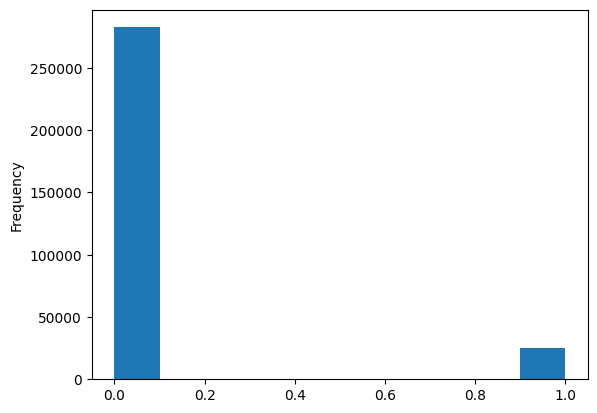

In [80]:
df['TARGET'].plot.hist()

In [61]:
import importlib
import srcs.utils
importlib.reload(srcs.utils)
from srcs.utils import *

# EDA - Categorical

## Null Values

# Old

In [197]:
check_null(df).head(20)

,percentage
COMMONAREA_MEDI,69.872297
COMMONAREA_AVG,69.872297
COMMONAREA_MODE,69.872297
NONLIVINGAPARTMENTS_MEDI,69.432963
NONLIVINGAPARTMENTS_MODE,69.432963
NONLIVINGAPARTMENTS_AVG,69.432963
FONDKAPREMONT_MODE,68.386172
LIVINGAPARTMENTS_MODE,68.354953
LIVINGAPARTMENTS_MEDI,68.354953
LIVINGAPARTMENTS_AVG,68.354953


In [107]:
df.dtypes.value_counts()

float64    65
int64      41
str        16
Name: count, dtype: int64

In [112]:
df.select_dtypes("str").nunique()

NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64

In [126]:
print(df.select_dtypes("str")['EMERGENCYSTATE_MODE'].unique())


<StringArray>
['No', nan, 'Yes']
Length: 3, dtype: str


In [ ]:
exclude = ['OCCUPATION_TYPE','ORGANIZATION_TYPE']
for i in df.select_dtypes("str").columns:
    if i not in exclude:
        print(f"-------- unique values in column {i} -----------")
        print(df.select_dtypes("str")[i].unique())
        # for j in df.select_dtypes("str")[i].unique():
        #     # print(j,", ")
        #     print(j)

-------- unique values in column NAME_CONTRACT_TYPE -----------
<StringArray>
['Cash loans', 'Revolving loans']
Length: 2, dtype: str
-------- unique values in column CODE_GENDER -----------
<StringArray>
['M', 'F', 'XNA']
Length: 3, dtype: str
-------- unique values in column FLAG_OWN_CAR -----------
<StringArray>
['N', 'Y']
Length: 2, dtype: str
-------- unique values in column FLAG_OWN_REALTY -----------
<StringArray>
['Y', 'N']
Length: 2, dtype: str
-------- unique values in column NAME_TYPE_SUITE -----------
<StringArray>
[  'Unaccompanied',          'Family', 'Spouse, partner',        'Children',
         'Other_A',               nan,         'Other_B', 'Group of people']
Length: 8, dtype: str
-------- unique values in column NAME_INCOME_TYPE -----------
<StringArray>
[             'Working',        'State servant', 'Commercial associate',
            'Pensioner',           'Unemployed',              'Student',
          'Businessman',      'Maternity leave']
Length: 8, dtype: st

In [132]:
df.select_dtypes("int").columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
       'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'REGION_RATING_CLIENT',
       'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START',
       'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
       'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'FLAG_DOCUMENT_2',
       'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5',
       'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8',
       'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11',
       'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14',
       'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17',
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21'],
      dtype='str')

In [135]:
df.select_dtypes("int").nunique()

SK_ID_CURR                     307511
TARGET                              2
CNT_CHILDREN                       15
DAYS_BIRTH                      17460
DAYS_EMPLOYED                   12574
DAYS_ID_PUBLISH                  6168
FLAG_MOBIL                          2
FLAG_EMP_PHONE                      2
FLAG_WORK_PHONE                     2
FLAG_CONT_MOBILE                    2
FLAG_PHONE                          2
FLAG_EMAIL                          2
REGION_RATING_CLIENT                3
REGION_RATING_CLIENT_W_CITY         3
HOUR_APPR_PROCESS_START            24
REG_REGION_NOT_LIVE_REGION          2
REG_REGION_NOT_WORK_REGION          2
LIVE_REGION_NOT_WORK_REGION         2
REG_CITY_NOT_LIVE_CITY              2
REG_CITY_NOT_WORK_CITY              2
LIVE_CITY_NOT_WORK_CITY             2
FLAG_DOCUMENT_2                     2
FLAG_DOCUMENT_3                     2
FLAG_DOCUMENT_4                     2
FLAG_DOCUMENT_5                     2
FLAG_DOCUMENT_6                     2
FLAG_DOCUMEN

In [133]:
df.select_dtypes("int")

,SK_ID_CURR,TARGET,CNT_CHILDREN,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,...,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21
0,100002,1,0,-9461,-637,-2120,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
1,100003,0,0,-16765,-1188,-291,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,100004,0,0,-19046,-225,-2531,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,100006,0,0,-19005,-3039,-2437,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,100007,0,0,-19932,-3038,-3458,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,0,-9327,-236,-1982,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
307507,456252,0,0,-20775,365243,-4090,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
307508,456253,0,0,-14966,-7921,-5150,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
307509,456254,1,0,-11961,-4786,-931,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0


In [134]:
df.select_dtypes("float").columns

Index(['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_REGISTRATION', 'OWN_CAR_AGE',
       'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG',
       'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG',
       'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG',
       'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG',
       'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE',
       'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE',
       'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE',
       'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE',
       'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI',
       'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI',
       'COMMONAREA_MEDI', 'ELEVATORS_MEDI'

In [168]:
df.select_dtypes("float").nunique()[df.select_dtypes("float").nunique()>10].sort_values(ascending=False)

EXT_SOURCE_2                    119831
EXT_SOURCE_1                    114584
DAYS_REGISTRATION                15688
AMT_ANNUITY                      13672
AMT_CREDIT                        5603
LIVINGAREA_MODE                   5301
LIVINGAREA_MEDI                   5281
LIVINGAREA_AVG                    5199
TOTALAREA_MODE                    5116
BASEMENTAREA_MODE                 3841
BASEMENTAREA_AVG                  3780
DAYS_LAST_PHONE_CHANGE            3773
BASEMENTAREA_MEDI                 3772
LANDAREA_MODE                     3563
LANDAREA_MEDI                     3560
LANDAREA_AVG                      3527
NONLIVINGAREA_MODE                3327
NONLIVINGAREA_MEDI                3323
NONLIVINGAREA_AVG                 3290
COMMONAREA_MEDI                   3202
COMMONAREA_AVG                    3181
COMMONAREA_MODE                   3128
AMT_INCOME_TOTAL                  2548
APARTMENTS_AVG                    2339
LIVINGAPARTMENTS_AVG              1868
APARTMENTS_MEDI          

In [139]:
df.select_dtypes("float")

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,OWN_CAR_AGE,CNT_FAM_MEMBERS,EXT_SOURCE_1,EXT_SOURCE_2,...,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,202500.0,406597.5,24700.5,351000.0,0.018801,-3648.0,NaN,1.0,0.083037,0.262949,...,2.0,2.0,2.0,-1134.0,0.0,0.0,0.0,0.0,0.0,1.0
1,270000.0,1293502.5,35698.5,1129500.0,0.003541,-1186.0,NaN,2.0,0.311267,0.622246,...,0.0,1.0,0.0,-828.0,0.0,0.0,0.0,0.0,0.0,0.0
2,67500.0,135000.0,6750.0,135000.0,0.010032,-4260.0,26.0,1.0,NaN,0.555912,...,0.0,0.0,0.0,-815.0,0.0,0.0,0.0,0.0,0.0,0.0
3,135000.0,312682.5,29686.5,297000.0,0.008019,-9833.0,NaN,2.0,NaN,0.650442,...,0.0,2.0,0.0,-617.0,NaN,NaN,NaN,NaN,NaN,NaN
4,121500.0,513000.0,21865.5,513000.0,0.028663,-4311.0,NaN,1.0,NaN,0.322738,...,0.0,0.0,0.0,-1106.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,157500.0,254700.0,27558.0,225000.0,0.032561,-8456.0,NaN,1.0,0.145570,0.681632,...,0.0,0.0,0.0,-273.0,NaN,NaN,NaN,NaN,NaN,NaN
307507,72000.0,269550.0,12001.5,225000.0,0.025164,-4388.0,NaN,1.0,NaN,0.115992,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
307508,153000.0,677664.0,29979.0,585000.0,0.005002,-6737.0,NaN,1.0,0.744026,0.535722,...,0.0,6.0,0.0,-1909.0,1.0,0.0,0.0,1.0,0.0,1.0
307509,171000.0,370107.0,20205.0,319500.0,0.005313,-2562.0,NaN,2.0,NaN,0.514163,...,0.0,0.0,0.0,-322.0,0.0,0.0,0.0,0.0,0.0,0.0


In [113]:
df.select_dtypes("str").head()

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
0,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,reg oper account,block of flats,"Stone, brick",No
1,Cash loans,F,N,N,Family,State servant,Higher education,Married,House / apartment,Core staff,MONDAY,School,reg oper account,block of flats,Block,No
2,Revolving loans,M,Y,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,MONDAY,Government,NaN,NaN,NaN,NaN
3,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,NaN,NaN,NaN,NaN
4,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Core staff,THURSDAY,Religion,NaN,NaN,NaN,NaN


In [174]:
Q1 = df.select_dtypes(["int"]).quantile(0.25) #["int","float64"]
Q3 = df.select_dtypes(["int"]).quantile(0.75)
IQR = Q3 - Q1

outlier_counts = ((df.select_dtypes(["int"]) < (Q1 - 3 * IQR)) | 
                  (df.select_dtypes(["int"]) > (Q3 + 3 * IQR))).sum()

In [188]:
Q1['REGION_RATING_CLIENT'] - 3 * IQR['REGION_RATING_CLIENT']

np.float64(2.0)

In [193]:
Q3['REGION_RATING_CLIENT']

np.float64(2.0)

In [191]:
IQR['REGION_RATING_CLIENT']

np.float64(0.0)

In [192]:
Q1['REGION_RATING_CLIENT'] - 3 * IQR['REGION_RATING_CLIENT']

np.float64(2.0)

In [183]:
IQR

SK_ID_CURR                     177997.0
TARGET                              0.0
CNT_CHILDREN                        1.0
DAYS_BIRTH                       7269.0
DAYS_EMPLOYED                    2471.0
DAYS_ID_PUBLISH                  2579.0
FLAG_MOBIL                          0.0
FLAG_EMP_PHONE                      0.0
FLAG_WORK_PHONE                     0.0
FLAG_CONT_MOBILE                    0.0
FLAG_PHONE                          1.0
FLAG_EMAIL                          0.0
REGION_RATING_CLIENT                0.0
REGION_RATING_CLIENT_W_CITY         0.0
HOUR_APPR_PROCESS_START             4.0
REG_REGION_NOT_LIVE_REGION          0.0
REG_REGION_NOT_WORK_REGION          0.0
LIVE_REGION_NOT_WORK_REGION         0.0
REG_CITY_NOT_LIVE_CITY              0.0
REG_CITY_NOT_WORK_CITY              0.0
LIVE_CITY_NOT_WORK_CITY             0.0
FLAG_DOCUMENT_2                     0.0
FLAG_DOCUMENT_3                     1.0
FLAG_DOCUMENT_4                     0.0
FLAG_DOCUMENT_5                     0.0


In [184]:
outlier_counts

SK_ID_CURR                         0
TARGET                         24825
CNT_CHILDREN                     126
DAYS_BIRTH                         0
DAYS_EMPLOYED                  59624
DAYS_ID_PUBLISH                    0
FLAG_MOBIL                         1
FLAG_EMP_PHONE                 55386
FLAG_WORK_PHONE                61308
FLAG_CONT_MOBILE                 574
FLAG_PHONE                         0
FLAG_EMAIL                     17442
REGION_RATING_CLIENT           80527
REGION_RATING_CLIENT_W_CITY    78027
HOUR_APPR_PROCESS_START            0
REG_REGION_NOT_LIVE_REGION      4657
REG_REGION_NOT_WORK_REGION     15612
LIVE_REGION_NOT_WORK_REGION    12503
REG_CITY_NOT_LIVE_CITY         24039
REG_CITY_NOT_WORK_CITY         70867
LIVE_CITY_NOT_WORK_CITY        55215
FLAG_DOCUMENT_2                   13
FLAG_DOCUMENT_3                    0
FLAG_DOCUMENT_4                   25
FLAG_DOCUMENT_5                 4648
FLAG_DOCUMENT_6                27078
FLAG_DOCUMENT_7                   59
F

In [175]:
outlier_counts[outlier_counts > 1].sort_values(ascending=False)

REGION_RATING_CLIENT           80527
REGION_RATING_CLIENT_W_CITY    78027
REG_CITY_NOT_WORK_CITY         70867
FLAG_WORK_PHONE                61308
DAYS_EMPLOYED                  59624
FLAG_EMP_PHONE                 55386
LIVE_CITY_NOT_WORK_CITY        55215
FLAG_DOCUMENT_6                27078
FLAG_DOCUMENT_8                25024
TARGET                         24825
REG_CITY_NOT_LIVE_CITY         24039
FLAG_EMAIL                     17442
REG_REGION_NOT_WORK_REGION     15612
LIVE_REGION_NOT_WORK_REGION    12503
REG_REGION_NOT_LIVE_REGION      4657
FLAG_DOCUMENT_5                 4648
FLAG_DOCUMENT_16                3053
FLAG_DOCUMENT_18                2500
FLAG_DOCUMENT_11                1203
FLAG_DOCUMENT_9                 1198
FLAG_DOCUMENT_13                1084
FLAG_DOCUMENT_14                 903
FLAG_CONT_MOBILE                 574
FLAG_DOCUMENT_15                 372
FLAG_DOCUMENT_19                 183
FLAG_DOCUMENT_20                 156
CNT_CHILDREN                     126
F

In [176]:
outlier_pct = (outlier_counts / len(df) * 100).sort_values(ascending=False)
outlier_pct[outlier_pct > 10]  # only show columns worth caring about

REGION_RATING_CLIENT           26.186706
REGION_RATING_CLIENT_W_CITY    25.373726
REG_CITY_NOT_WORK_CITY         23.045354
FLAG_WORK_PHONE                19.936848
DAYS_EMPLOYED                  19.389225
FLAG_EMP_PHONE                 18.011063
LIVE_CITY_NOT_WORK_CITY        17.955455
dtype: float64

<Axes: ylabel='Frequency'>

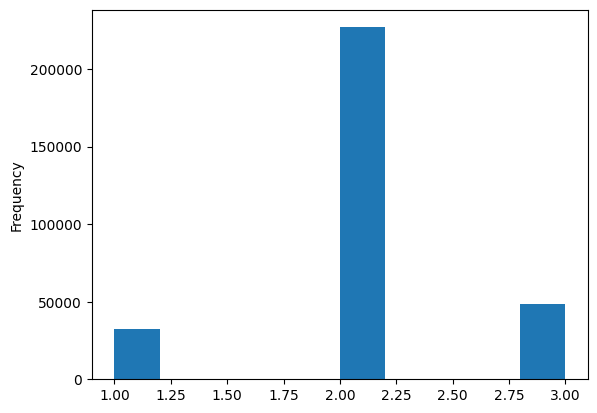

In [178]:
df['REGION_RATING_CLIENT'].plot.hist()

In [181]:
df['REGION_RATING_CLIENT'].value_counts()

REGION_RATING_CLIENT
2    226984
3     48330
1     32197
Name: count, dtype: int64

In [161]:
len(df)

307511